# Teaser: solve diffusion equation

**Python for HPC course**

Max Planck Computing and Data Facility, Garching

## Teaser: solving the diffusion equation
* Example of solving a PDE with python
* Solve the diffusion equation $\partial_t u= \alpha (\partial_x^2 + \partial_y^2) u$ in 2D
* Use equidistant quadratic grid with periodic boundaries
* Formula for time update of $u$ at position $x_i,y_j$ from time $t_n$ to $t_{n+1}$: 
$$ u_{i,j}^{(n+1)} = u_{i,j}^{(n)} + \frac{\alpha \Delta t}{\Delta x^2} \left( 
u_{i-1,j}^{(n)}
+u_{i+1,j}^{(n)}
+u_{i,j-1}^{(n)}
+u_{i,j+1}^{(n)}
-4u_{i,j}^{(n)}
\right) $$
* How fast are different implementations?

## Set up parameters and initial conditions

In [1]:
import os
os.environ["OMP_NUM_THREADS"]="1"
os.environ["KMP_NUM_THREADS"]="1"

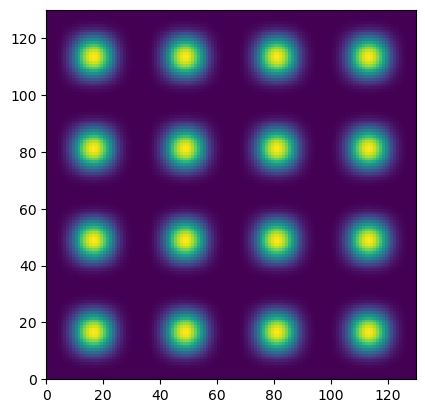

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# parameters
n_iterations = 400; n_points = 128; dt = 0.1; D = 1.0
def init(val=0.005):
    x = np.linspace(0., 4.*np.pi, num=n_points+2)
    y = np.linspace(0., 4.*np.pi, num=n_points+2)
    grid = val * np.outer(np.sin(x)**4, np.sin(y)**4)
    return grid
grid = init()
plt.pcolormesh(grid.T); plt.axis('image'); plt.show()

## Simple python version with loops

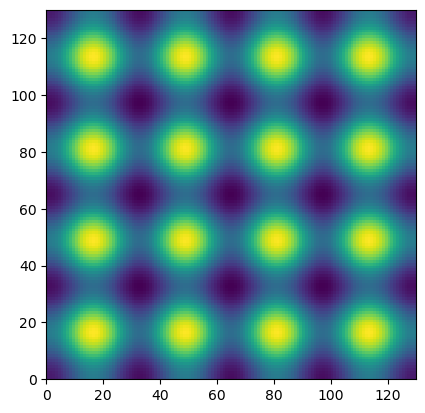

CPU times: user 12.6 s, sys: 7.86 ms, total: 12.6 s
Wall time: 12.6 s


In [3]:
%%time
grid = init()
grid_tmp = np.zeros_like(grid)
for k in range(1, n_iterations+1):
    for j in range(n_points + 2):      # apply periodic boundary conditions
        grid[ 0, j] = grid[-2, j]
        grid[-1, j] = grid[ 1, j]
    for i in range(n_points + 2):
        grid[ i,-1] = grid[ i, 1]
        grid[ i, 0] = grid[ i,-2]
    for i in range(1, n_points+1):     # finite difference formula
        for j in range(1, n_points+1):
            grid_tmp[i, j] = grid[i, j] + dt * D * (
                grid[i-1, j] + grid[i+1, j] + grid[i, j-1] + grid[i, j+1] - 4.0 * grid[i, j])
    for i in range(1, n_points+1):     # update grid
        for j in range(1, n_points+1):
            grid[i,j] = grid_tmp[i,j]
plt.pcolormesh(grid.T); plt.axis('image');  plt.show()

## NumPy

In [4]:
grid = init()

In [5]:
%%time

for k in range(1, n_iterations+1):
    grid[ 0, :] = grid[-2, :]    # apply periodic boundary conditions
    grid[-1, :] = grid[ 1, :]
    grid[ :,-1] = grid[ :, 1]
    grid[ :, 0] = grid[ :,-2]
    # finite difference formula with arrays
    grid[1:-1, 1:-1] = grid[1:-1, 1:-1] + dt * D * (
        grid[0:-2, 1:-1] + grid[2:  , 1:-1] + grid[1:-1, 0:-2] + grid[1:-1, 2:  ] - 4.0 * grid[1:-1, 1:-1])

#plt.pcolormesh(grid.T); plt.axis('image'); plt.show()

CPU times: user 99 ms, sys: 0 ns, total: 99 ms
Wall time: 98.5 ms


$\to$ factor 200 faster!
Can we get even faster?

### Just-in-Time Compilation

In [6]:
import numba

In [7]:
@numba.jit
def evolve_numba(grid, dt, D, n_iterations):
    for k in range(1, n_iterations+1):
        grid[ 0, :] = grid[-2, :]    # apply periodic boundary conditions
        grid[-1, :] = grid[ 1, :]
        grid[ :,-1] = grid[ :, 1]
        grid[ :, 0] = grid[ :,-2]
        # finite difference formula with arrays
        grid[1:-1, 1:-1] = grid[1:-1, 1:-1] + dt * D * (
            grid[0:-2, 1:-1] + grid[2:  , 1:-1] + grid[1:-1, 0:-2] + grid[1:-1, 2:  ] - 4.0 * grid[1:-1, 1:-1])

In [8]:
grid = init()
# warmup call to trigger JIT
evolve_numba(grid, dt, D, 10)

In [9]:
grid = init()

In [10]:
%%time
evolve_numba(grid, dt, D, n_iterations)
#plt.pcolormesh(grid.T); plt.axis('image'); plt.show()

CPU times: user 84.1 ms, sys: 0 ns, total: 84.1 ms
Wall time: 83.4 ms


## Conclusion: Python for HPC
* Python: rapid development of code
* With some tricks and effort, good performance is possible

$\to$ goal of this workshop!